Initial Parameters
------------------
w1 = 0.5425600435859647
w2 = -0.46341769281246226
bias = -0.46572975357025687
ephoc 1
loss 0.6143190895243247
ephoc 2
loss 0.6004610731897805
ephoc 5
loss 0.5650170998818406
ephoc 10
loss 0.5173045753753729
ephoc 25
loss 0.416298771090841
ephoc 50
loss 0.3191033142657046
ephoc 100
loss 0.22302473900507538
ephoc 250
loss 0.11924135624818202
ephoc 500
loss 0.06633131310684735
ephoc 1000
loss 0.0345298707445995

Final Learned Parameters
------------------------
w1 = 6.023139089929733
w2 = 6.023121569155369
bias = -9.211912236850871

AND Gate Predictions
-----------------------------------------
X1   X2   Probability   Prediction Target
-----------------------------------------
0    0    0.0001        0          0
0    1    0.0396        0          0
1    0    0.0396        0          0
1    1    0.9445        1          1


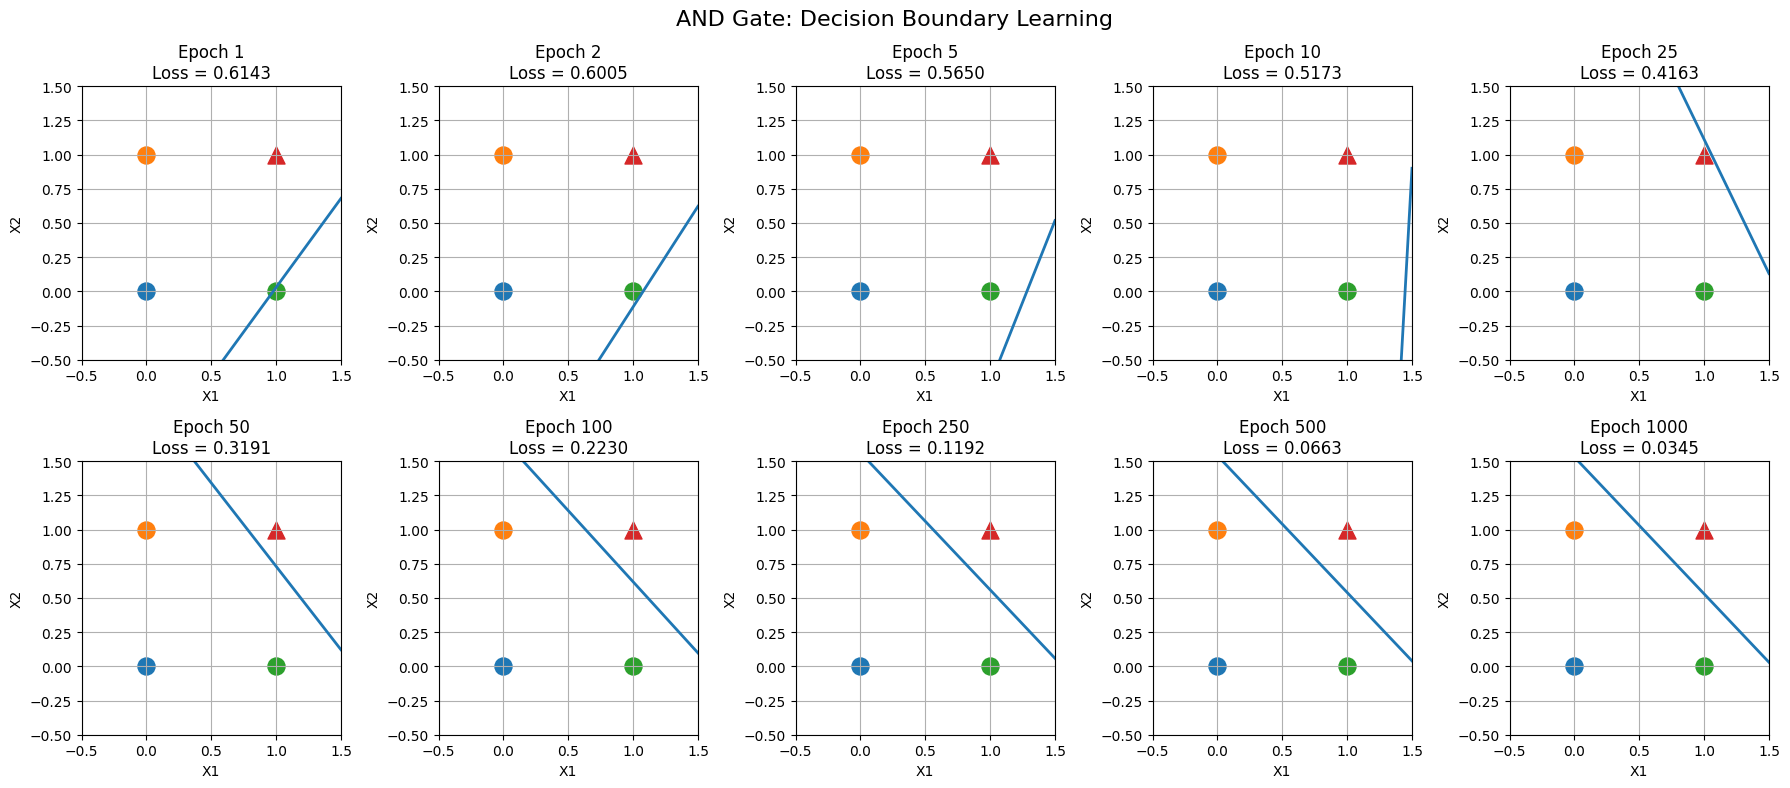

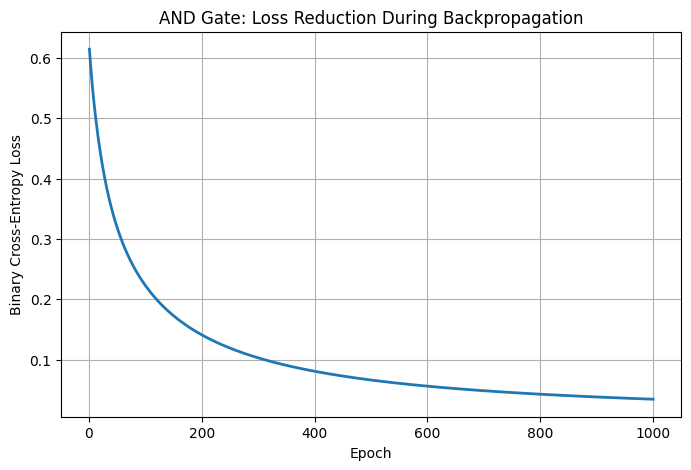

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. AND GATE DATA
# ==========================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=float)


# ==========================================================
# 2. SIGMOID ACTIVATION FUNCTION
# ==========================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ==========================================================
# 3. INITIALIZE WEIGHTS AND BIAS
# ==========================================================

#np.random.seed(42)

w1 = np.random.randn()
w2 = np.random.randn()
b = np.random.randn()
#w1=0
#w2=0
#b=0

print("Initial Parameters")
print("------------------")
print("w1 =", w1)
print("w2 =", w2)
print("bias =", b)


# ==========================================================
# 4. TRAINING PARAMETERS
# ==========================================================

learning_rate = 0.5
epochs = 1000

# Store loss for every epoch
loss_history = []

# Store parameters at selected epochs
epoch_history = []

selected_epochs = [
    1, 2, 5, 10, 25,
    50, 100, 250, 500, 1000
]


# ==========================================================
# 5. BACKPROPAGATION TRAINING
# ==========================================================

for epoch in range(1, epochs + 1):

    # ------------------------------------------------------
    # FORWARD PROPAGATION
    # ------------------------------------------------------

    z = w1 * X[:, 0] + w2 * X[:, 1] + b

    y_pred = sigmoid(z)


    # ------------------------------------------------------
    # CALCULATE BINARY CROSS-ENTROPY LOSS
    # ------------------------------------------------------

    loss = -np.mean(
        y.flatten() * np.log(y_pred + 1e-8)
        +
        (1 - y.flatten()) *
        np.log(1 - y_pred + 1e-8)
    )

    loss_history.append(loss)


    # ------------------------------------------------------
    # BACKPROPAGATION
    # ------------------------------------------------------

    error = y_pred - y.flatten()

    # Gradients
    dw1 = np.mean(error * X[:, 0])
    dw2 = np.mean(error * X[:, 1])
    db = np.mean(error)


    # ------------------------------------------------------
    # UPDATE WEIGHTS AND BIAS
    # ------------------------------------------------------

    w1 = w1 - learning_rate * dw1
    w2 = w2 - learning_rate * dw2
    b = b - learning_rate * db


    # ------------------------------------------------------
    # STORE PARAMETERS
    # ------------------------------------------------------

    if epoch in selected_epochs:

        epoch_history.append({
            "epoch": epoch,
            "w1": w1,
            "w2": w2,
            "b": b,
            "loss": loss,

        })
        print("ephoc",epoch)
        print("w1",w1)
        print("w2",w2)
        print("bias",b)
        print("loss",loss)


# ==========================================================
# 6. DISPLAY LEARNED PARAMETERS
# ==========================================================

print("\nFinal Learned Parameters")
print("------------------------")
print("w1 =", w1)
print("w2 =", w2)
print("bias =", b)


# ==========================================================
# 7. FINAL PREDICTION
# ==========================================================

z = w1 * X[:, 0] + w2 * X[:, 1] + b

probabilities = sigmoid(z)

predictions = (probabilities >= 0.5).astype(int)


print("\nAND Gate Predictions")
print("-----------------------------------------")
print("X1   X2   Probability   Prediction Target")
print("-----------------------------------------")

for i in range(len(X)):

    print(
        f"{int(X[i,0])}    "
        f"{int(X[i,1])}    "
        f"{probabilities[i]:.4f}        "
        f"{predictions[i]}          "
        f"{int(y[i,0])}"
    )


# ==========================================================
# 8. VISUALIZE DECISION BOUNDARY AT DIFFERENT EPOCHS
# ==========================================================

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

x_boundary = np.linspace(-0.5, 1.5, 100)


for ax, record in zip(
    axes.ravel(),
    epoch_history
):

    w1_plot = record["w1"]
    w2_plot = record["w2"]
    b_plot = record["b"]

    # ------------------------------------------------------
    # Decision boundary:
    #
    # w1*x1 + w2*x2 + b = 0
    #
    # Therefore:
    #
    # x2 = -(w1*x1 + b) / w2
    # ------------------------------------------------------

    if abs(w2_plot) > 1e-10:

        y_boundary = (
            -(w1_plot * x_boundary + b_plot)
            / w2_plot
        )

        ax.plot(
            x_boundary,
            y_boundary,
            linewidth=2,
            label="Decision Boundary"
        )


    # ------------------------------------------------------
    # Plot AND gate data
    # ------------------------------------------------------

    for i in range(len(X)):

        if y[i, 0] == 0:

            ax.scatter(
                X[i, 0],
                X[i, 1],
                s=150,
                marker="o"
            )

        else:

            ax.scatter(
                X[i, 0],
                X[i, 1],
                s=150,
                marker="^"
            )


    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    ax.set_title(
        f"Epoch {record['epoch']}\n"
        f"Loss = {record['loss']:.4f}"
    )

    ax.grid(True)


plt.suptitle(
    "AND Gate: Decision Boundary Learning",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ==========================================================
# 9. LOSS VS EPOCH
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "AND Gate: Loss Reduction During Backpropagation"
)

plt.grid(True)

plt.show()